# PSNR vs CR at matched EPOCHS — NYX (left) & Miranda 1024³ (right)

Both panels train for the same number of epochs (`FIXED_EPOCHS`), which fixes the
number of gradient steps on identical data regardless of model size -- the standard
protocol for isolating a capacity effect, since wall-clock time depends on hardware/
implementation rather than being a property of the model. The wall-clock version
(`nyx_miranda_scale.ipynb`) instead fixes seconds per config, which lets a small model
finish ~22 epochs on Miranda while a large one gets ~3 in the same 80 s -- so its
apparent lack of scaling was undertraining, not a property of the data.

**Parameter targets.** NYX sweeps five roughly geometric steps up to its paper
main-table configuration (30k, `bg_h=21`), so its reported operating point is the
largest model shown. Miranda 1024³ sweeps 75k / 136k / 240k / 400k / 500k
(`bg_h` 34/46/61/79/88): the paper's main-table configuration (240k, `bg_h=61`) sits
in the middle, with two larger models beyond it to test whether capacity scaling
continues past the operating point.

Both datasets are aligned to effective CR 100-500. Speed cost (seconds/config) is
reported alongside quality so the trade-off stays visible.

In [1]:
import random, sys, os, copy, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")

import importlib
import bg_stage
importlib.reload(bg_stage)

from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
from bg_shard import pick_bg_h_under_budget

pysz_dir = "/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_dir not in sys.path:
    sys.path.append(pysz_dir)
from pysz import SZ

def set_seed(seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda:1 | GPUs: 2


In [2]:
# ── Shared engine + helpers (identical pipeline for both datasets) ─────────────
halo_finder_root = Path("/home/sam/Halo_Finder")
sz_lib_path = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
sz_engine   = SZ(sz_lib_path)

BYTES_PER_PARAM = 2      # bf16 storage for the model weights
FIXED_LR        = 1e-3
FREQ_WARMUP     = 1      # epochs before the FFT/freq loss term joins the loss
H_CANDIDATES    = list(range(3, 256))  # default range(3,100) is fine here but kept wide

def psnr_from_arrays(target, recon):
    data_range = float(target.max() - target.min())
    if data_range <= 0:
        data_range = 1.0
    mse = float(np.mean((target - recon) ** 2))
    return 100.0 if mse <= 0 else 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

def build_cfg(Xs_in, Xps_in, max_train_time, bg_h, steps_per_epoch,
              lr=1e-4, epochs=200, log_prefix="", patch_size=None, bg_batch=1):
    if patch_size is None:
        patch_size = Xs_in[0].shape[2]
    cfg = build_bg_only_cfg(
        X_target=Xs_in[0], Xps=Xps_in, max_train_time=max_train_time,
        epochs=epochs, steps_per_epoch=steps_per_epoch, bg_h=bg_h,
        bg_batch=int(bg_batch), bg_patch_size=patch_size, lr=lr,
    )
    cfg.bg_sample_mode   = "sequential"
    cfg.bg_log_prefix    = log_prefix
    cfg.bg_arch          = "spatial"
    cfg.amp              = True
    cfg.amp_dtype        = "bf16"
    cfg.bg_ddp           = False
    cfg.bg_data_parallel = False
    return cfg

def n_params_of(model):
    return int(sum(p.numel() for p in unwrap_bg_model(model).parameters()))

def build_sweep_plan(param_targets, work_shape, n_fields):
    """Map each param budget -> largest bg_h that fits; dedupe & sort."""
    seen, plan = set(), []
    for tgt in param_targets:
        h, est_p = pick_bg_h_under_budget(
            tgt, shape=work_shape, n_fields=n_fields,
            bg_arch="spatial", h_candidates=H_CANDIDATES,
        )
        if h not in seen:
            seen.add(h)
            plan.append((int(h), int(est_p)))
    plan.sort()
    return plan

def run_sweep(gt, Xs, compress_at, orig_bytes, work_shape,
              rel_errs, sweep_plan, time_per_config, label="", bg_batch=1,
              fixed_epochs=None):
    """Full rel-error × model-size sweep for ONE dataset.

    `compress_at(vol, rel)` -> (Xps_list, sz_bytes, sz_cr); Xps_list[0] is the
    SZ3-decompressed target, plus any aux conditioning fields. Only sz_bytes (the
    target stream) is counted in CR. Returns (results, baselines).

    fixed_epochs pins the epoch count instead of the wall-clock budget. Under a fixed
    time budget a bigger model simply completes fewer epochs -- on Miranda 1024^3 the
    2.6k-parameter model gets ~22 epochs in 80 s while the 238k one gets ~3 -- so the
    capacity advantage is cancelled by undertraining and the curves collapse onto each
    other. That measures "capacity gain minus undertraining loss", not capacity. Pinning
    epochs separates the two; the speed cost of depth/width is reported separately as
    seconds per config."""
    depth    = work_shape[0]
    patch_sz = work_shape[2]

    # GPU warm-up (not timed) using the loosest rel_err
    _w_Xps, _, _ = compress_at(gt, max(rel_errs))
    _wcfg = build_cfg(Xs, _w_Xps, max_train_time=0.5, bg_h=4,
                      steps_per_epoch=2, lr=1e-3, epochs=1, log_prefix="warmup",
                      bg_batch=bg_batch)
    set_seed(42)
    train_bg_only(Xs=Xs, Xps=_w_Xps, device=device, cfg=_wcfg,
                  evaluator=lambda m, c=_wcfg: (0.0, 0.0))
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    del _w_Xps
    print(f"[{label}] GPU warm-up done\n")

    results, baselines = [], []
    sweep_t0 = time.time()
    for rel in rel_errs:
        Xps_list, sz_bytes, sz_cr = compress_at(gt, rel)
        base_psnr = psnr_from_arrays(gt, Xps_list[0])
        base_cr   = orig_bytes / sz_bytes
        baselines.append(dict(rel=rel, cr=base_cr, psnr=base_psnr, sz_mb=sz_bytes/1e6))
        print(f"\n{'#'*60}")
        print(f"# [{label}] rel={rel:.0e} | SZ3 base: CR={base_cr:.2f}x "
              f"({sz_bytes/1e6:.2f} MB) | base PSNR={base_psnr:.2f} dB")

        for bg_h, est_p in sweep_plan:
            # steps_per_epoch MUST shrink with the batch: one epoch is still one pass
            # over `depth` slices. Raising bg_batch alone would silently make each
            # "epoch" consume bg_batch x more data and wreck the timing comparison.
            _mt  = 1e9 if fixed_epochs else time_per_config
            _eps = int(fixed_epochs) if fixed_epochs else 200
            cfg = build_cfg(Xs, Xps_list, max_train_time=_mt, bg_h=bg_h,
                            steps_per_epoch=max(1, depth // int(bg_batch)),
                            lr=FIXED_LR, epochs=_eps, bg_batch=bg_batch,
                            log_prefix=f"{label}-r{rel:.0e}-h{bg_h}", patch_size=patch_sz)
            cfg.bg_early_stop         = False
            cfg.bg_freq_warmup_epochs = FREQ_WARMUP

            def evaluator(m, c=cfg, Xp=Xps_list, rel=rel):
                xh = run_bg_inference(unwrap_bg_model(m), Xs, Xp, c, rel)
                return psnr_from_arrays(gt, xh), 0.0

            set_seed(42)
            _t0 = time.time()
            model, hist = train_bg_only(Xs=Xs, Xps=Xps_list, device=device,
                                        cfg=cfg, evaluator=evaluator)
            _wall = time.time() - _t0

            n_params    = n_params_of(model)
            psnr_vals   = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
            psnr        = max(psnr_vals) if psnr_vals else float("nan")
            model_bytes = n_params * BYTES_PER_PARAM
            cr          = orig_bytes / (sz_bytes + model_bytes)
            results.append(dict(rel=rel, bg_h=bg_h, n_params=n_params, psnr=psnr, cr=cr,
                                model_mb=model_bytes/1e6, sz_mb=sz_bytes/1e6,
                                epochs=len(hist.get("loss", [])), wall=_wall))
            print(f"  bg_h={bg_h:2d} ({n_params:,}p): PSNR={psnr:.2f} dB | CR={cr:.2f}x "
                  f"(base {base_cr:.2f}x) | +{psnr-base_psnr:.2f} dB over SZ3 "
                  f"| {len(hist.get('loss', []))} ep / {_wall:.1f}s")
            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

        del Xps_list

    print(f"\n--- [{label}] sweep complete in {(time.time()-sweep_t0)/60:.1f} min "
          f"({len(results)} models over {len(rel_errs)} rel-errors) ---")
    return results, baselines

print("Shared helpers ready")

Shared helpers ready


## NYX — 512³ multi-field (target `baryon_density` + 5 aux conditioning fields)

In [3]:
# ── NYX 512³ load + config (5 aux) ────────────────────────────────────────────
FIXED_EPOCHS      = 10
# Capped at 30k for NYX and 240k for Miranda (the 8x ratio below), i.e. the paper's
# main-table configuration is the LARGEST point rather than a mid-sweep one. Five
# roughly geometric steps up to that cap; each maps to a distinct bg_h (6/8/11/15/21).
NYX_PARAM_TARGETS = [3000, 5000, 9500, 17000, 30000]

nyx_dir      = halo_finder_root / "halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin"
NYX_TARGET   = "baryon_density"
NYX_AUX      = ["dark_matter_density", "temperature", "velocity_x", "velocity_y", "velocity_z"]
NYX_PATHS    = {f: (nyx_dir / f"{f}.f32").as_posix() for f in [NYX_TARGET] + NYX_AUX}
NYX_SHAPE    = (512, 512, 512)

def _nyx_load_field(name):
    return np.fromfile(NYX_PATHS[name], dtype=np.float32).reshape(NYX_SHAPE)

t0 = time.time()
gt_nyx    = _nyx_load_field(NYX_TARGET)
aux_nyx   = [_nyx_load_field(f) for f in NYX_AUX]
Xs_nyx    = [gt_nyx] + aux_nyx
ws_nyx    = gt_nyx.shape
orig_nyx  = gt_nyx.nbytes

def compress_at_nyx(vol, rel_err):
    b, cr = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq  = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    return [np.asarray(x_lq, np.float32)] + aux_nyx, int(len(b)), float(cr)

NYX_REL_ERRS   = [1.3827e-06, 2.3587e-06, 4.0235e-06, 6.8636e-06, 1.1708e-05]  # SZ3 CR 100-500
sweep_plan_nyx = build_sweep_plan(NYX_PARAM_TARGETS, ws_nyx, n_fields=len(Xs_nyx))

print(f"NYX loaded in {time.time()-t0:.1f}s | shape {ws_nyx} | n_fields={len(Xs_nyx)}")
for h, est_p in sweep_plan_nyx:
    print(f"  bg_h={h:2d}  ~{est_p:,} params")
print(f">> {len(NYX_REL_ERRS)*len(sweep_plan_nyx)} trainings at {FIXED_EPOCHS} epochs each")

results_nyx, baselines_nyx = run_sweep(
    gt_nyx, Xs_nyx, compress_at_nyx, orig_nyx, ws_nyx,
    NYX_REL_ERRS, sweep_plan_nyx, None, label="NYX",
    fixed_epochs=FIXED_EPOCHS)

del gt_nyx, aux_nyx, Xs_nyx     # free ~3 GB before Miranda
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Params] Main (BG) Network : 8,683 parameters

[Model: spatial] Total Params: 10,228
 [Params] Main (BG) Network : 10,228 parameters

[Model: spatial] Total Params: 11,899
 [Params] Main (BG) Network : 11,899 parameters

[Model: spatial] Total Params: 13,696
 [Params] Main (BG) Networ


[Model: spatial] Total Params: 858,868
 [Params] Main (BG) Network : 858,868 parameters

[Model: spatial] Total Params: 873,643
 [Params] Main (BG) Network : 873,643 parameters

[Model: spatial] Total Params: 888,544
 [Params] Main (BG) Network : 888,544 parameters

[Model: spatial] Total Params: 903,571
 [Params] Main (BG) Network : 903,571 parameters

[Model: spatial] Total Params: 918,724
 [Params] Main (BG) Network : 918,724 parameters

[Model: spatial] Total Params: 934,003
 [Params] Main (BG) Network : 934,003 parameters

[Model: spatial] Total Params: 949,408
 [Params] Main (BG) Network : 949,408 parameters

[Model: spatial] Total Params: 964,939
 [Params] Main (BG) Network : 964,939 parameters

[Model: spatial] Total Params: 980,596
 [Params] Main (BG) Network : 980,596 parameters

[Model: spatial] Total Params: 996,379
 [Params] Main (BG) Network : 996,379 parameters

[Model: spatial] Total Params: 1,012,288
 [Params] Main (BG) Network : 1,012,288 parameters

[Model: spatial]


[Model: spatial] Total Params: 1,394,164
 [Params] Main (BG) Network : 1,394,164 parameters

[Model: spatial] Total Params: 1,412,971
 [Params] Main (BG) Network : 1,412,971 parameters

[Model: spatial] Total Params: 1,431,904
 [Params] Main (BG) Network : 1,431,904 parameters

[Model: spatial] Total Params: 1,450,963
 [Params] Main (BG) Network : 1,450,963 parameters

[Model: spatial] Total Params: 1,470,148
 [Params] Main (BG) Network : 1,470,148 parameters

[Model: spatial] Total Params: 1,489,459
 [Params] Main (BG) Network : 1,489,459 parameters

[Model: spatial] Total Params: 1,508,896
 [Params] Main (BG) Network : 1,508,896 parameters

[Model: spatial] Total Params: 1,528,459
 [Params] Main (BG) Network : 1,528,459 parameters

[Model: spatial] Total Params: 1,548,148
 [Params] Main (BG) Network : 1,548,148 parameters

[Model: spatial] Total Params: 1,567,963
 [Params] Main (BG) Network : 1,567,963 parameters

[Model: spatial] Total Params: 1,587,904
 [Params] Main (BG) Network 


[Model: spatial] Total Params: 1,880,308
 [Params] Main (BG) Network : 1,880,308 parameters

[Model: spatial] Total Params: 1,902,139
 [Params] Main (BG) Network : 1,902,139 parameters

[Model: spatial] Total Params: 1,924,096
 [Params] Main (BG) Network : 1,924,096 parameters

[Model: spatial] Total Params: 1,946,179
 [Params] Main (BG) Network : 1,946,179 parameters

[Model: spatial] Total Params: 1,968,388
 [Params] Main (BG) Network : 1,968,388 parameters

[Model: spatial] Total Params: 1,990,723
 [Params] Main (BG) Network : 1,990,723 parameters

[Model: spatial] Total Params: 2,013,184
 [Params] Main (BG) Network : 2,013,184 parameters

[Model: spatial] Total Params: 2,035,771
 [Params] Main (BG) Network : 2,035,771 parameters

[Model: spatial] Total Params: 2,058,484
 [Params] Main (BG) Network : 2,058,484 parameters

[Model: spatial] Total Params: 2,081,323
 [Params] Main (BG) Network : 2,081,323 parameters

[Model: spatial] Total Params: 2,104,288
 [Params] Main (BG) Network 


[Model: spatial] Total Params: 2,340,868
 [Params] Main (BG) Network : 2,340,868 parameters

[Model: spatial] Total Params: 2,365,219
 [Params] Main (BG) Network : 2,365,219 parameters

[Model: spatial] Total Params: 2,389,696
 [Params] Main (BG) Network : 2,389,696 parameters

[Model: spatial] Total Params: 2,414,299
 [Params] Main (BG) Network : 2,414,299 parameters

[Model: spatial] Total Params: 2,439,028
 [Params] Main (BG) Network : 2,439,028 parameters

[Model: spatial] Total Params: 2,463,883
 [Params] Main (BG) Network : 2,463,883 parameters

[Model: spatial] Total Params: 2,488,864
 [Params] Main (BG) Network : 2,488,864 parameters

[Model: spatial] Total Params: 2,513,971
 [Params] Main (BG) Network : 2,513,971 parameters

[Model: spatial] Total Params: 2,539,204
 [Params] Main (BG) Network : 2,539,204 parameters

[Model: spatial] Total Params: 2,564,563
 [Params] Main (BG) Network : 2,564,563 parameters

[Model: spatial] Total Params: 2,590,048
 [Params] Main (BG) Network 

...

NYX-r1e-05-h21 Epoch   6 [BG] | train_wall=1.41s | Loss: 0.521832 | Freq: 0.423647 | Global: 121.21 dB | MaxErr: 0.0  [New Best!]


NYX-r1e-05-h21 Epoch   7 [BG] | train_wall=1.42s | Loss: 0.506799 | Freq: 0.413811 | Global: 121.40 dB | MaxErr: 0.0  [New Best!]


NYX-r1e-05-h21 Epoch   8 [BG] | train_wall=1.50s | Loss: 0.497232 | Freq: 0.407705 | Global: 121.58 dB | MaxErr: 0.0  [New Best!]


NYX-r1e-05-h21 Epoch   9 [BG] | train_wall=1.48s | Loss: 0.493635 | Freq: 0.406007 | Global: 121.76 dB | MaxErr: 0.0  [New Best!]


NYX-r1e-05-h21 Epoch  10 [BG] | train_wall=1.47s | Loss: 0.496259 | Freq: 0.409041 | Global: 121.91 dB | MaxErr: 0.0  [New Best!]

NYX-r1e-05-h21 --- Experiment [BG_only] finished ---
NYX-r1e-05-h21 --- Pure training time: 15.02 s ---
NYX-r1e-05-h21 [timing] epochs=10 | train_wall/epoch: mean=1.46s min=1.41s max=1.50s | sum=14.57s
NYX-r1e-05-h21 --- Best global PSNR: 121.91 dB ---
  bg_h=21 (29,803p): PSNR=121.91 dB | CR=469.75x (base 495.59x) | +10.58 dB over SZ3 | 10 ep / 40.7s

--- [NYX] sweep complete in 17.2 min (25 models over 5 rel-errors) ---


## Miranda 1024³ — single field, no aux conditioning (75k–500k parameter sweep)

In [4]:
# ── Miranda 1024³ load + config ───────────────────────────────────────────────
# Sweep centred on the paper's main-table Miranda config (240k, bg_h=61) and extended
# UPWARD: 75k/136k/240k/400k/500k -> bg_h 34/46/61/79/88 (~74.6k/135.7k/237.5k/
# 397.2k/492.4k params), to show whether capacity scaling continues past the paper's
# operating point rather than stopping at it.
MIR_FILE      = "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw"
MIR_SRC_SHAPE = (1024, 1024, 1024)
MIR_STRIDE    = 1

def _mir_load(stride=1):
    vol = np.fromfile(MIR_FILE, dtype=np.float32).reshape(MIR_SRC_SHAPE)
    if stride > 1:
        vol = np.ascontiguousarray(vol[::stride, ::stride, ::stride])
    return vol

t0 = time.time()
gt_mir   = _mir_load(MIR_STRIDE)
Xs_mir   = [gt_mir]
ws_mir   = gt_mir.shape
orig_mir = gt_mir.nbytes

def compress_at_mir(vol, rel_err):
    b, cr = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq  = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    return [np.asarray(x_lq, np.float32)], int(len(b)), float(cr)

MIR_REL_ERRS      = [4.5523e-03, 6.9948e-03, 1.0748e-02, 1.6514e-02, 2.5374e-02]  # SZ3 CR 100-500
MIR_PARAM_TARGETS = [75_000, 136_000, 240_000, 400_000, 500_000]
sweep_plan_mir    = build_sweep_plan(MIR_PARAM_TARGETS, ws_mir, n_fields=1)

print(f"Miranda loaded in {time.time()-t0:.1f}s | shape {ws_mir} | "
      f"{orig_mir/1e6:.1f} MB | n_fields=1")
for h, est_p in sweep_plan_mir:
    print(f"  bg_h={h:2d}  ~{est_p:,} params")
print(f">> {len(MIR_REL_ERRS)*len(sweep_plan_mir)} trainings at {FIXED_EPOCHS} epochs each")

results_mir, baselines_mir = run_sweep(
    gt_mir, Xs_mir, compress_at_mir, orig_mir, ws_mir,
    MIR_REL_ERRS, sweep_plan_mir, None, label="Miranda",
    fixed_epochs=FIXED_EPOCHS)

del gt_mir, Xs_mir
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 13,066
 [Params] Main (BG) Network 


[Model: spatial] Total Params: 1,350,358
 [Params] Main (BG) Network : 1,350,358 parameters

[Model: spatial] Total Params: 1,368,868
 [Params] Main (BG) Network : 1,368,868 parameters

[Model: spatial] Total Params: 1,387,504
 [Params] Main (BG) Network : 1,387,504 parameters

[Model: spatial] Total Params: 1,406,266
 [Params] Main (BG) Network : 1,406,266 parameters

[Model: spatial] Total Params: 1,425,154
 [Params] Main (BG) Network : 1,425,154 parameters

[Model: spatial] Total Params: 1,444,168
 [Params] Main (BG) Network : 1,444,168 parameters

[Model: spatial] Total Params: 1,463,308
 [Params] Main (BG) Network : 1,463,308 parameters

[Model: spatial] Total Params: 1,482,574
 [Params] Main (BG) Network : 1,482,574 parameters

[Model: spatial] Total Params: 1,501,966
 [Params] Main (BG) Network : 1,501,966 parameters

[Model: spatial] Total Params: 1,521,484
 [Params] Main (BG) Network : 1,521,484 parameters

[Model: spatial] Total Params: 1,541,128
 [Params] Main (BG) Network 


[Model: spatial] Total Params: 2,356,534
 [Params] Main (BG) Network : 2,356,534 parameters

[Model: spatial] Total Params: 2,380,966
 [Params] Main (BG) Network : 2,380,966 parameters

[Model: spatial] Total Params: 2,405,524
 [Params] Main (BG) Network : 2,405,524 parameters

[Model: spatial] Total Params: 2,430,208
 [Params] Main (BG) Network : 2,430,208 parameters

[Model: spatial] Total Params: 2,455,018
 [Params] Main (BG) Network : 2,455,018 parameters

[Model: spatial] Total Params: 2,479,954
 [Params] Main (BG) Network : 2,479,954 parameters

[Model: spatial] Total Params: 2,505,016
 [Params] Main (BG) Network : 2,505,016 parameters

[Model: spatial] Total Params: 2,530,204
 [Params] Main (BG) Network : 2,530,204 parameters

[Model: spatial] Total Params: 2,555,518
 [Params] Main (BG) Network : 2,555,518 parameters

[Model: spatial] Total Params: 2,580,958
 [Params] Main (BG) Network : 2,580,958 parameters

[Model: spatial] Total Params: 2,606,524
 [Params] Main (BG) Network 


[Model: spatial] Total Params: 3,200,854
 [Params] Main (BG) Network : 3,200,854 parameters

[Model: spatial] Total Params: 3,229,318
 [Params] Main (BG) Network : 3,229,318 parameters

[Model: spatial] Total Params: 3,257,908
 [Params] Main (BG) Network : 3,257,908 parameters

[Model: spatial] Total Params: 3,286,624
 [Params] Main (BG) Network : 3,286,624 parameters

[Model: spatial] Total Params: 3,315,466
 [Params] Main (BG) Network : 3,315,466 parameters

[Model: spatial] Total Params: 3,344,434
 [Params] Main (BG) Network : 3,344,434 parameters

[Model: spatial] Total Params: 3,373,528
 [Params] Main (BG) Network : 3,373,528 parameters

[Model: spatial] Total Params: 3,402,748
 [Params] Main (BG) Network : 3,402,748 parameters

[Model: spatial] Total Params: 3,432,094
 [Params] Main (BG) Network : 3,432,094 parameters

[Model: spatial] Total Params: 3,461,566
 [Params] Main (BG) Network : 3,461,566 parameters

[Model: spatial] Total Params: 3,491,164
 [Params] Main (BG) Network 


[Model: spatial] Total Params: 3,950,254
 [Params] Main (BG) Network : 3,950,254 parameters

[Model: spatial] Total Params: 3,981,868
 [Params] Main (BG) Network : 3,981,868 parameters

[Model: spatial] Total Params: 4,013,608
 [Params] Main (BG) Network : 4,013,608 parameters

[Model: spatial] Total Params: 4,045,474
 [Params] Main (BG) Network : 4,045,474 parameters

[Model: spatial] Total Params: 4,077,466
 [Params] Main (BG) Network : 4,077,466 parameters

[Model: spatial] Total Params: 4,109,584
 [Params] Main (BG) Network : 4,109,584 parameters

[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Tot

...

Miranda-r3e-02-h88 Epoch   6 [BG] | train_wall=34.84s | Loss: 0.963433 | Freq: 0.398424 | Global: 44.80 dB | MaxErr: 0.0  [New Best!]


Miranda-r3e-02-h88 Epoch   7 [BG] | train_wall=34.82s | Loss: 0.953656 | Freq: 0.394090 | Global: 44.89 dB | MaxErr: 0.0  [New Best!]


Miranda-r3e-02-h88 Epoch   8 [BG] | train_wall=34.82s | Loss: 0.945408 | Freq: 0.390856 | Global: 45.01 dB | MaxErr: 0.0  [New Best!]


Miranda-r3e-02-h88 Epoch   9 [BG] | train_wall=34.76s | Loss: 0.940994 | Freq: 0.388884 | Global: 45.09 dB | MaxErr: 0.0  [New Best!]


Miranda-r3e-02-h88 Epoch  10 [BG] | train_wall=34.78s | Loss: 0.939011 | Freq: 0.388126 | Global: 45.11 dB | MaxErr: 0.0  [New Best!]

Miranda-r3e-02-h88 --- Experiment [BG_only] finished ---
Miranda-r3e-02-h88 --- Pure training time: 348.45 s ---
Miranda-r3e-02-h88 [timing] epochs=10 | train_wall/epoch: mean=34.78s min=34.61s max=34.84s | sum=347.85s
Miranda-r3e-02-h88 --- Best global PSNR: 45.11 dB ---
  bg_h=88 (492,364p): PSNR=45.11 dB | CR=448.53x (base 499.94x) | +2.60 dB over SZ3 | 10 ep / 674.8s

--- [Miranda] sweep complete in 214.4 min (25 models over 5 rel-errors) ---


## Combined figure — NYX (left) & Miranda 1024³ (right), matched epochs

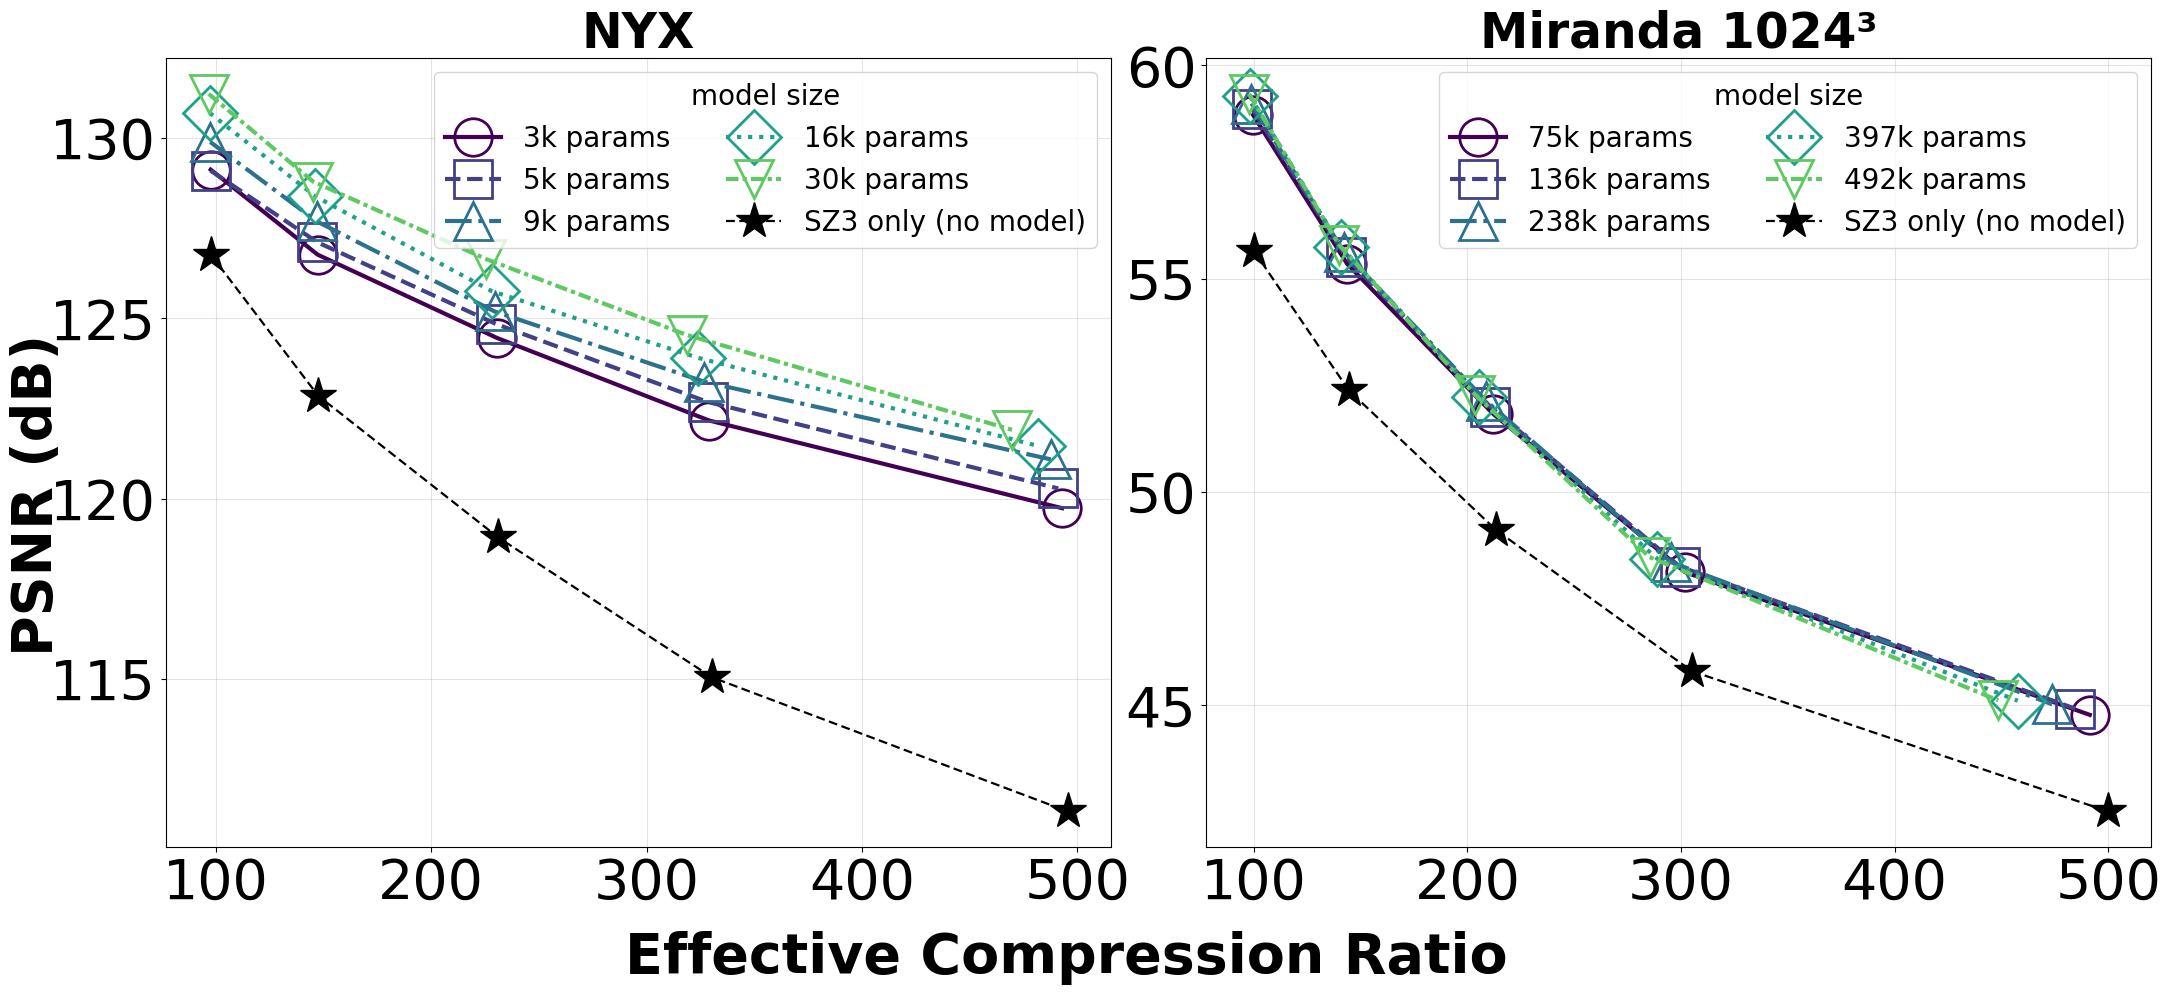

Saved: psnr_vs_cr_isoepoch_nyx_miranda500k.pdf


In [5]:
MARKERS    = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]

def _fmt_p(p):
    return f"{p/1000:.0f}k" if p >= 1000 else str(p)

def plot_rd(ax, results, baselines, panel_title, show_legend=True):
    param_sizes = sorted(set(r["n_params"] for r in results))
    cmap   = plt.cm.viridis
    colors = {p: cmap((i / max(1, len(param_sizes) - 1)) * 0.75)
              for i, p in enumerate(param_sizes)}
    for i, p in enumerate(param_sizes):
        pts = sorted([r for r in results if r["n_params"] == p], key=lambda r: r["cr"])
        ax.plot([r["cr"] for r in pts], [r["psnr"] for r in pts],
                marker=MARKERS[i % len(MARKERS)], linestyle=LINESTYLES[i % len(LINESTYLES)],
                color=colors[p], markerfacecolor='none', markeredgewidth=2.0,
                markersize=27, linewidth=3, zorder=3, label=f"{_fmt_p(p)}")
    bl = sorted(baselines, key=lambda b: b["cr"])
    ax.plot([b["cr"] for b in bl], [b["psnr"] for b in bl], marker="*",
            linestyle=(0, (4, 2)), color="black", markersize=27, linewidth=1.6,
            zorder=2, label="SZ3 only")
    ax.tick_params(axis='both', which='major', labelsize=40)
    ax.grid(True, alpha=0.35)
    ax.set_xticks([100, 200, 300, 400, 500])
    ax.set_title(panel_title, fontsize=35, fontweight='bold', y=1.34)
    if show_legend:
        # legend ABOVE the panel (under its title), bigger font, no frame
        ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), fontsize=34,
                  ncol=3, frameon=False, handletextpad=0.3, columnspacing=0.8,
                  handlelength=1.2, markerscale=0.7)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
plot_rd(axes[0], results_nyx, baselines_nyx, "NYX", show_legend=True)
plot_rd(axes[1], results_mir, baselines_mir, "Miranda", show_legend=True)
fig.supxlabel("Effective Compression Ratio", fontsize=40, fontweight='bold')
fig.supylabel("PSNR (dB)", fontsize=40, fontweight='bold')
plt.tight_layout()
out_pdf = "psnr_vs_cr_isoepoch_nyx_miranda500k.pdf"
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")

In [6]:
# ── Capacity effect at matched epochs, speed cost shown separately ──
def summarise(results, baselines, name):
    bl = {b["rel"]: b["psnr"] for b in baselines}
    print(f"\n=== {name} ===")
    print(f"{'params':>9s} {'bg_h':>5s} {'mean gain':>10s} {'epochs':>7s} {'sec/config':>11s}")
    ks = sorted(set(r["n_params"] for r in results))
    for p in ks:
        rs = [r for r in results if r["n_params"] == p]
        g  = np.mean([r["psnr"] - bl[r["rel"]] for r in rs])
        print(f"{p:9,} {rs[0]['bg_h']:5d} {g:+10.3f} {np.mean([r['epochs'] for r in rs]):7.1f} "
              f"{np.mean([r.get('wall', float('nan')) for r in rs]):11.1f}")
    lo = np.mean([r["psnr"] - bl[r["rel"]] for r in results if r["n_params"] == ks[0]])
    hi = np.mean([r["psnr"] - bl[r["rel"]] for r in results if r["n_params"] == ks[-1]])
    print(f">> capacity gain {ks[0]:,} -> {ks[-1]:,}: {hi-lo:+.3f} dB")
    print("per-CR gain by model size:")
    for p in ks:
        rs = sorted([r for r in results if r["n_params"] == p], key=lambda r: r["cr"])
        print(f"  {p:8,}: " + " ".join(f"{r['psnr']-bl[r['rel']]:+6.2f}" for r in rs))

summarise(results_nyx, baselines_nyx, "NYX (5 aux)")
summarise(results_mir, baselines_mir, "Miranda 1024³ (single field, 75k-500k targets)")


=== NYX (5 aux) ===
   params  bg_h  mean gain  epochs  sec/config
    2,848     6     +5.463    10.0        36.6
    4,804     8     +5.816    10.0        36.5
    8,683    11     +6.434    10.0        37.5
   15,619    15     +7.052    10.0        38.4
   29,803    21     +7.635    10.0        41.1
>> capacity gain 2,848 -> 29,803: +2.173 dB
per-CR gain by model size:
     2,848:  +2.36  +3.91  +5.53  +7.11  +8.40
     4,804:  +2.33  +4.25  +5.91  +7.63  +8.95
     8,683:  +3.13  +4.83  +6.26  +8.19  +9.76
    15,619:  +3.93  +5.52  +6.83  +8.85 +10.13
    29,803:  +4.46  +5.94  +7.72  +9.49 +10.58

=== Miranda 1024³ (single field, 75k-500k targets) ===
   params  bg_h  mean gain  epochs  sec/config
   74,566    34     +2.692    10.0       350.2
  135,658    46     +2.841    10.0       386.8
  237,538    61     +2.962    10.0       465.0
  397,216    79     +3.067    10.0       627.4
  492,364    88     +3.110    10.0       675.5
>> capacity gain 74,566 -> 492,364: +0.418 dB
per-CR 